In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from readrbdata import load

import matplotlib.pyplot as plt
from fittingutils import *
%matplotlib widget

In [2]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)
len(sat.time), len(uns.time)

(13269, 13246)

In [3]:
uns_data_interp = np.interp(sat.time, uns.time, uns.signal)
diff_signal = sat.signal - uns_data_interp

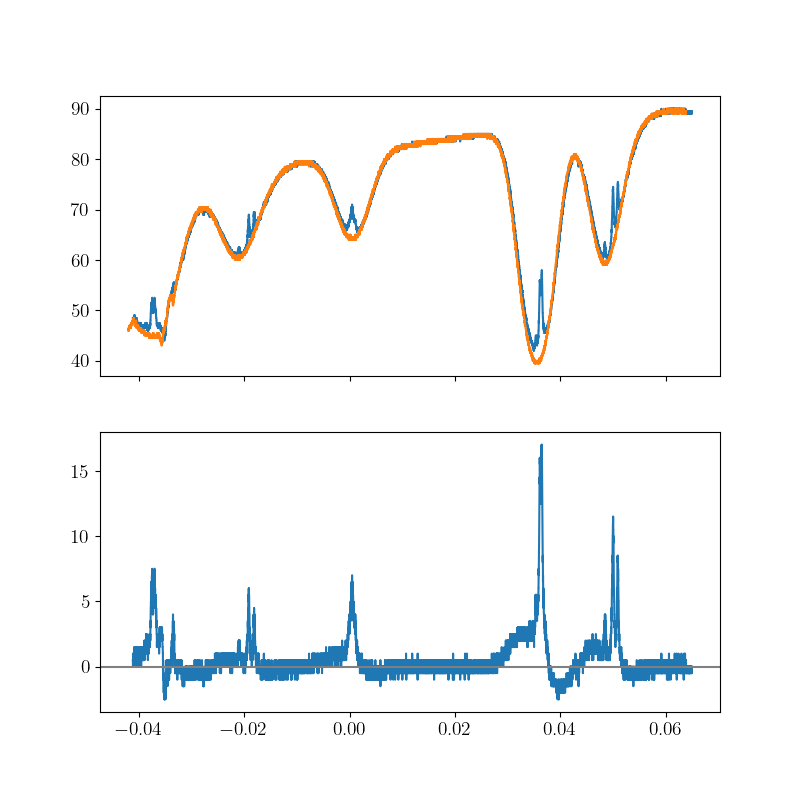

In [4]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(8, 8))

sig_ax.plot(sat.time, sat.signal)
sig_ax.plot(uns.time, uns.signal)

diff_ax.plot(sat.time, diff_signal)
diff_ax.axhline(0., color="gray")

let's try curve fitting the easiest one

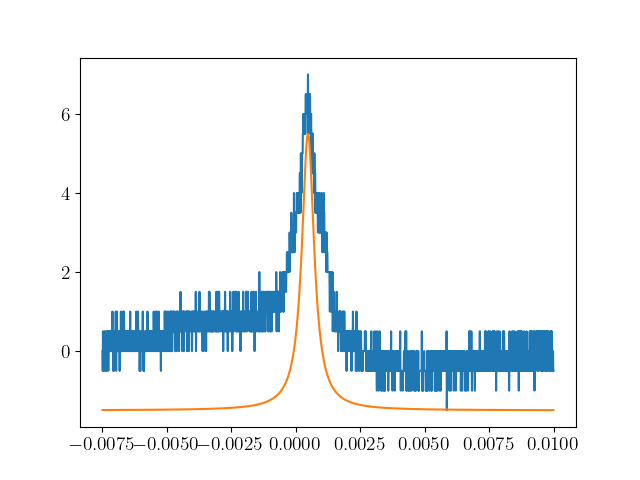

In [7]:
spidx, = np.nonzero((-0.0075 <= sat.time) & (sat.time < 0.01)) # single peak indices

x = sat.time[spidx]
y = diff_signal[spidx]

p0 = [
    x[np.argmax(diff_signal[spidx])],
    Lorentzian.guess_gamma(x, y),
    np.max(y),
    np.min(y)
]

fig, ax = plt.subplots()

ax.plot(x, y)
ax.plot(x, Lorentzian(x, *p0))

In [12]:
fit_params, cov = curve_fit(Lorentzian, x, y, p0)

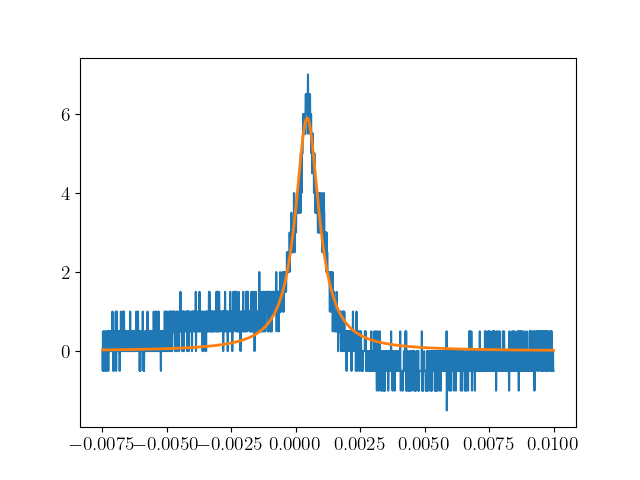

In [35]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.plot(x, Lorentzian(x, *fit_params), lw=2)